#### First let's define our sin wave and plot it 

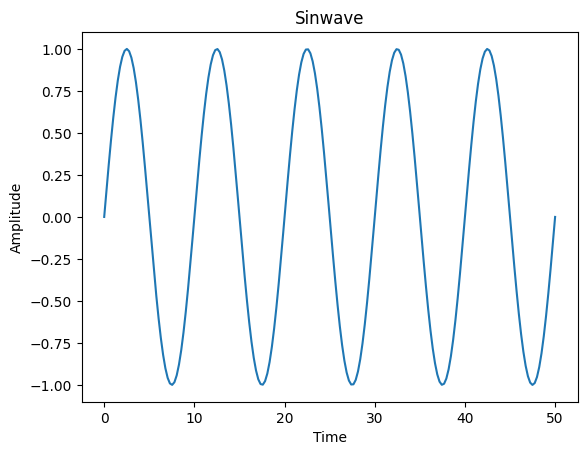

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

f = 0.1 
A = 1 
duration = 50 
fs = 200

t = np.linspace(0,duration, fs)

y = A*np.sin(2*np.pi*f*t)

plt.plot(t,y)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Sinwave")
plt.show()








#### Next, we will plot its ACF and PACF 

-8.881784197001253e-18
0.4975


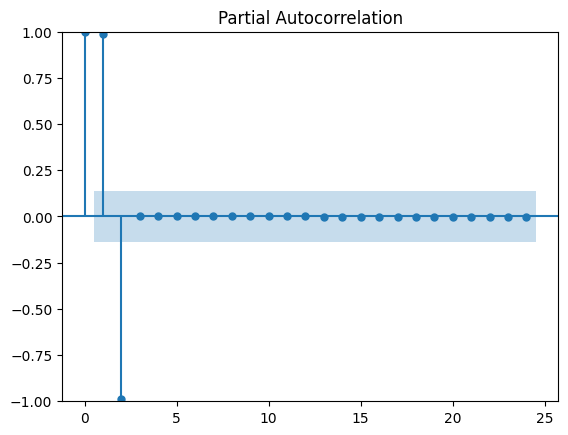

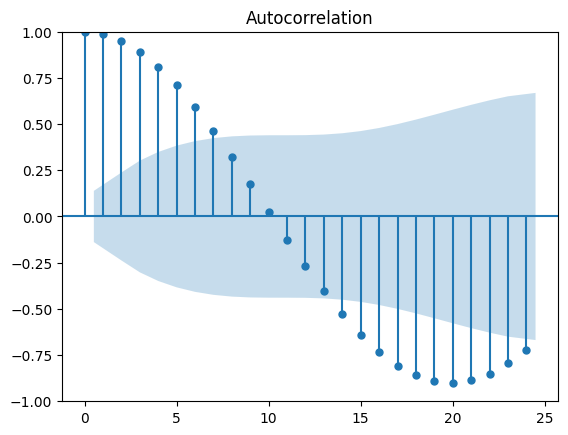

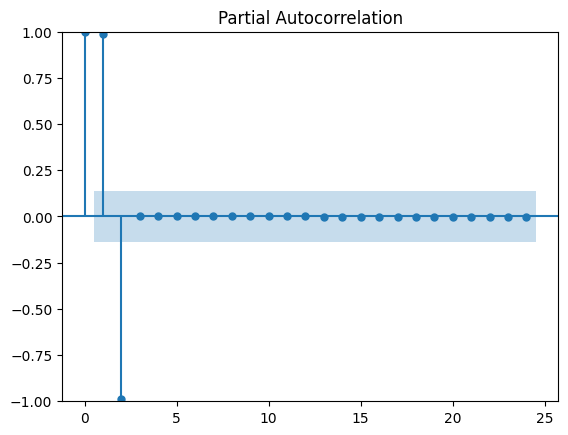

In [2]:
from statsmodels.graphics.tsaplots import plot_acf 
from statsmodels.graphics.tsaplots import plot_pacf 

mean = np.mean(y)
print(mean)

variance = np.var(y)
print(variance)


plot_acf(y)
plot_pacf(y)



#### Next, we will fit an ARIMA of (1,0,1), (2,0,0), (0,0,2). The PACF shows a complete drop after lag 3, so im assuming that the best results for AR will come from p = 3, which is closest to the last one. However, the ACF shows periodicity, meaning that a simple ARIMA will likely not be suitable. 




c:\Users\Jeff\anaconda3\envs\research\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\Jeff\anaconda3\envs\research\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Jeff\anaconda3\envs\research\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 287.955
Date:                Sun, 03 May 2026   AIC                           -567.911
Time:                        00:33:36   BIC                           -554.718
Sample:                             0   HQIC                          -562.572
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.253e-06      0.487  -2.57e-06      1.000      -0.954       0.954
ar.L1          0.9837      0.014     68.895      0.000       0.956       1.012
ma.L1          0.9998      7.795      0.128      0.8

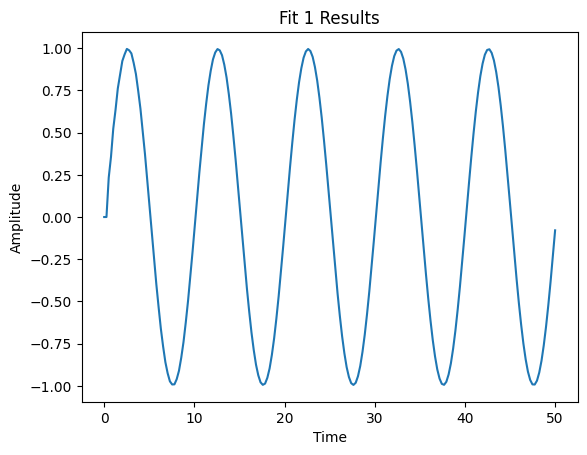

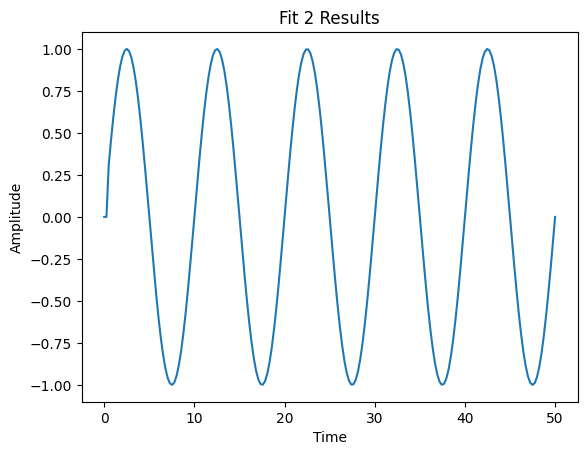

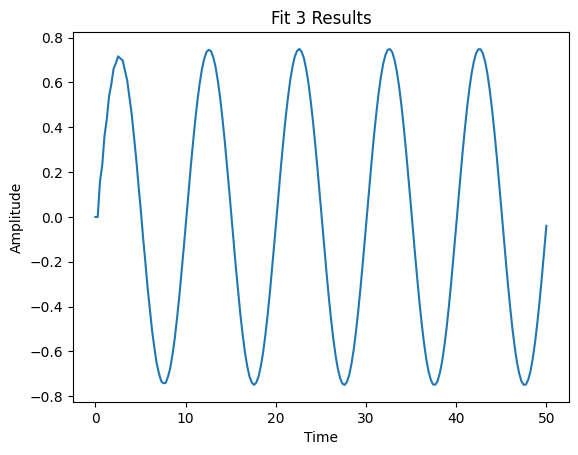

In [3]:
from statsmodels.tsa.arima.model import ARIMA 

model_1 = ARIMA(y, order = (1,0,1))

fit_1 = model_1.fit()

model_2 = ARIMA(y, order = (2,0,0))

fit_2 = model_2.fit()

model_3 = ARIMA(y, order = (0,0,2))

fit_3 = model_3.fit()

fitted_values_1 = fit_1.predict()

fitted_values_2 = fit_2.predict()

fitted_values_3 = fit_3.predict()

plt.figure()
plt.plot(t,fitted_values_1)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Fit 1 Results")

plt.figure()
plt.plot(t,fitted_values_2)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Fit 2 Results")

plt.figure()
plt.plot(t,fitted_values_3)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Fit 3 Results")

print(fit_1.summary())
print(fit_2.summary())
print(fit_3.summary())



#### AIC for the ARIMA(2,0,0) gives us the lowest AIC and therefore the best result. Let's compute the residuals. 

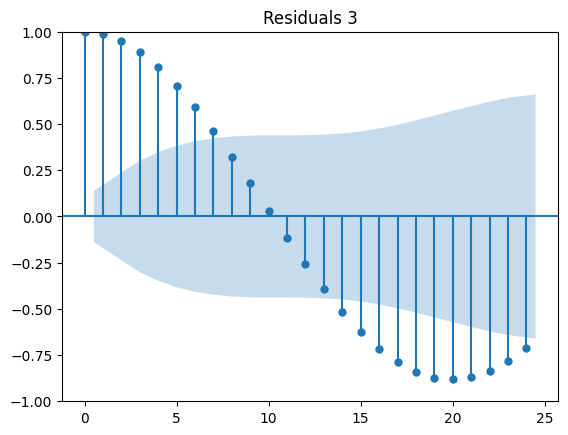

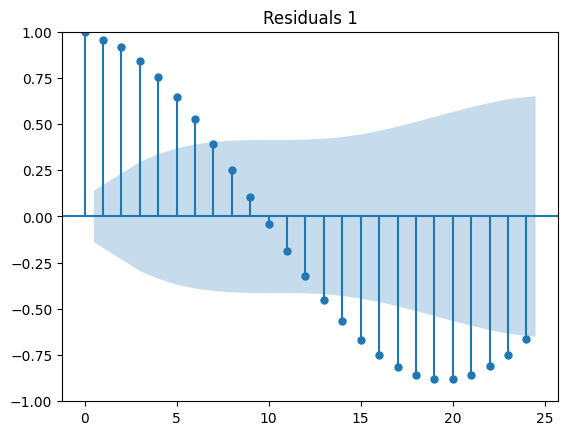

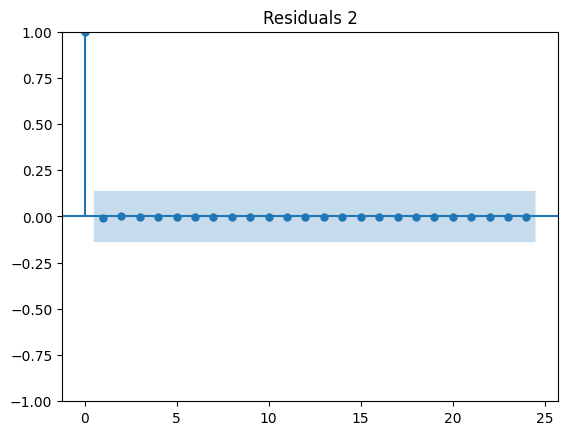

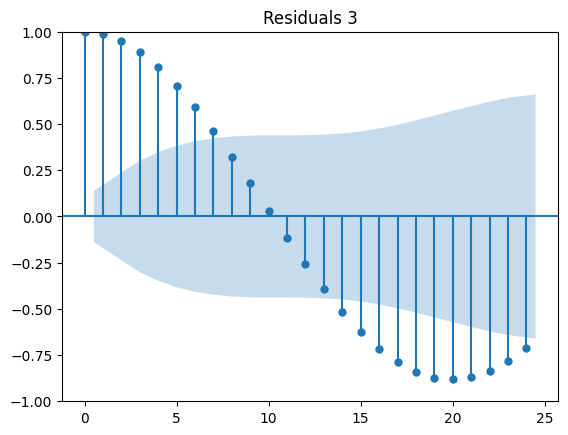

In [4]:

residuals_1 = fit_1.resid
residuals_2 = fit_2.resid
residuals_3 = fit_3.resid

plot_acf(residuals_1, title = "Residuals 1")

plot_acf(residuals_2, title = "Residuals 2")

plot_acf(residuals_3, title = "Residuals 3")




#### Fit 2 gave us almost no residuals, which means the model was a good fit, but we should be careful of overfitting. We want the residuals to look like white noise. Next, let's create another sin wave with noise this time and repeat the process. 

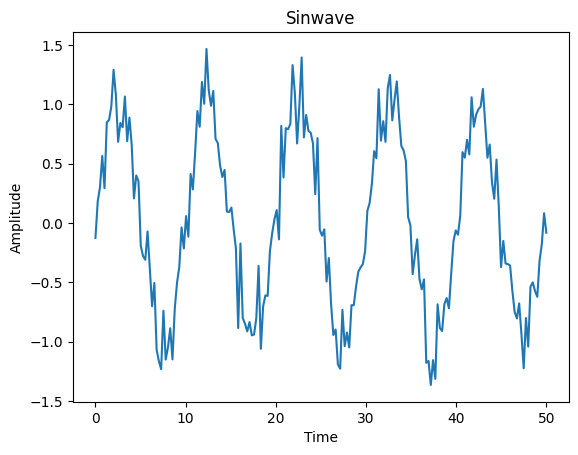

In [5]:
f = 0.1 
A = 1 
duration = 50 
fs = 200

rng = np.random.default_rng()

noise = rng.normal( loc = 0, scale = 0.2, size = 200)

t = np.linspace(0,duration, fs)

y = A*np.sin(2*np.pi*f*t) + noise

plt.plot(t,y)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Sinwave")
plt.show()

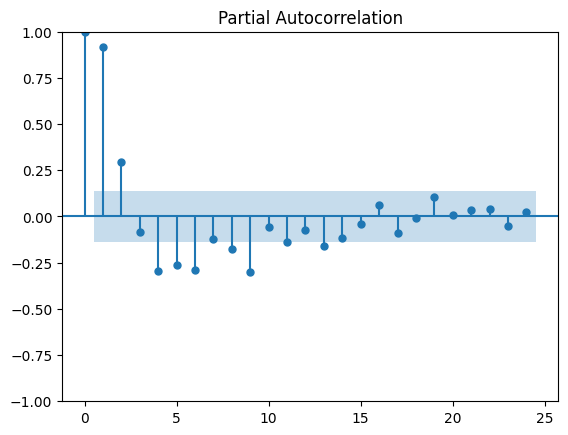

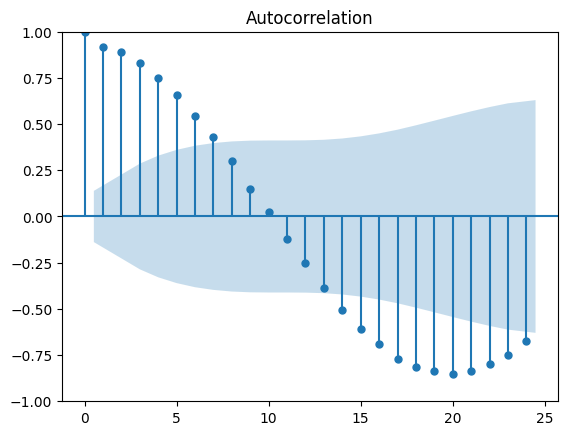

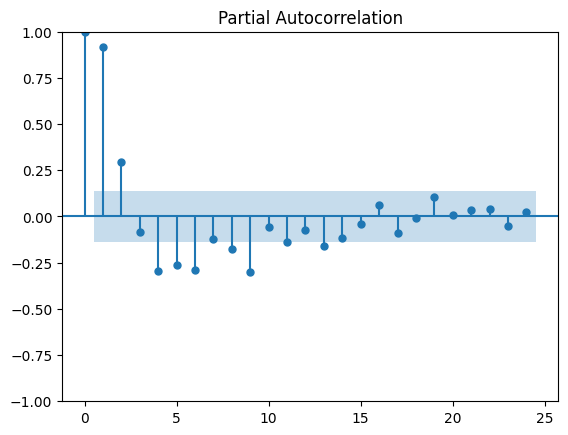

In [6]:
plot_acf(y)
plot_pacf(y)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  200
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 -31.828
Date:                Sun, 03 May 2026   AIC                             71.656
Time:                        00:33:48   BIC                             84.849
Sample:                             0   HQIC                            76.995
                                - 200                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0035      0.297      0.012      0.990      -0.578       0.585
ar.L1          0.9473      0.025     37.269      0.000       0.897       0.997
ma.L1         -0.2159      0.085     -2.525      0.0

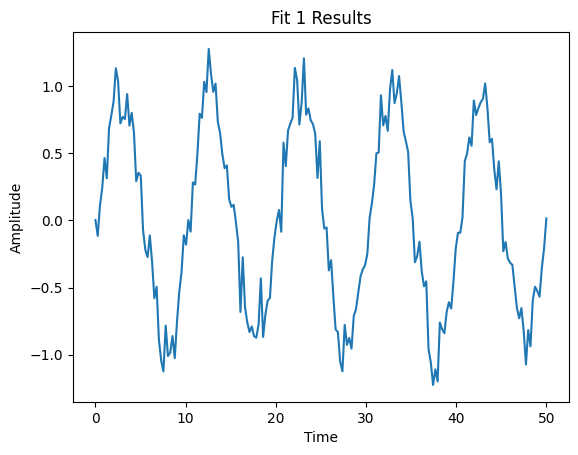

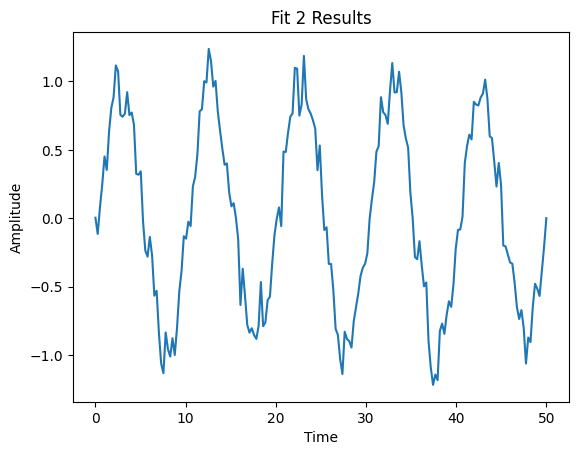

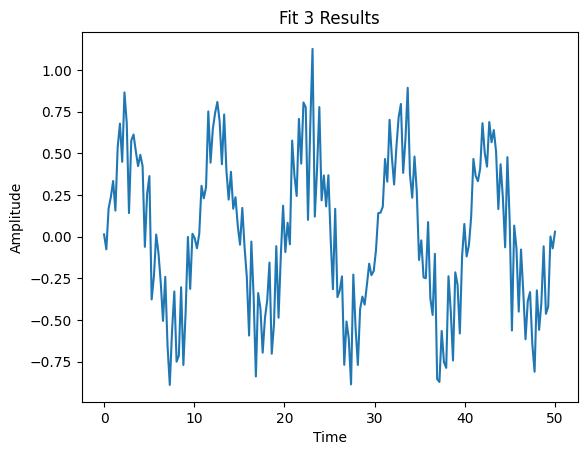

In [7]:
model_1 = ARIMA(y, order = (1,0,1))

fit_1 = model_1.fit()

model_2 = ARIMA(y, order = (2,0,0))

fit_2 = model_2.fit()

model_3 = ARIMA(y, order = (0,0,2))

fit_3 = model_3.fit()

fitted_values_1 = fit_1.predict()

fitted_values_2 = fit_2.predict()

fitted_values_3 = fit_3.predict()

plt.figure()
plt.plot(t,fitted_values_1)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Fit 1 Results")

plt.figure()
plt.plot(t,fitted_values_2)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Fit 2 Results")

plt.figure()
plt.plot(t,fitted_values_3)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title("Fit 3 Results")

print(fit_1.summary())
print(fit_2.summary())
print(fit_3.summary())



#### Fit 2 still gives us the lowest BIC and AIC results. 

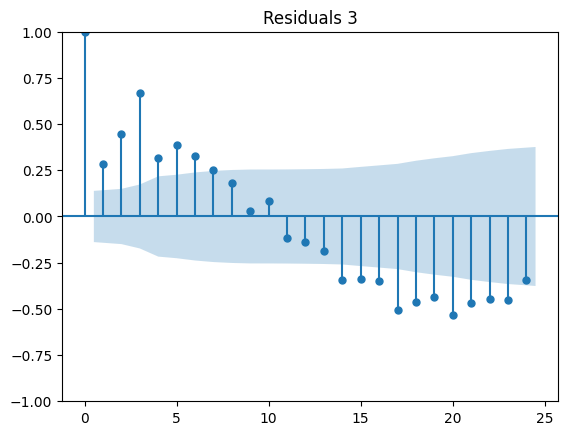

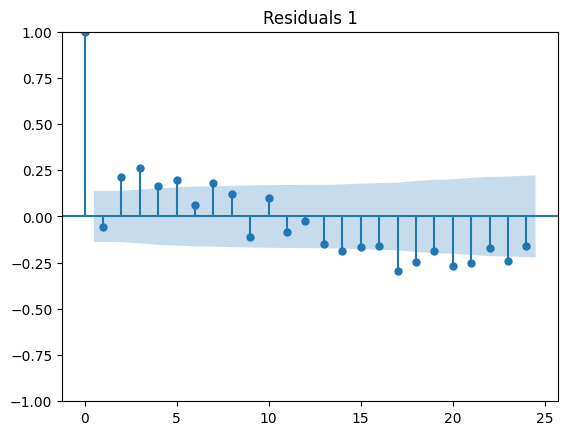

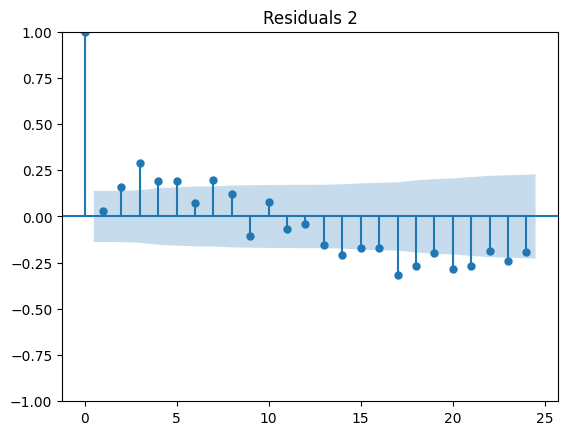

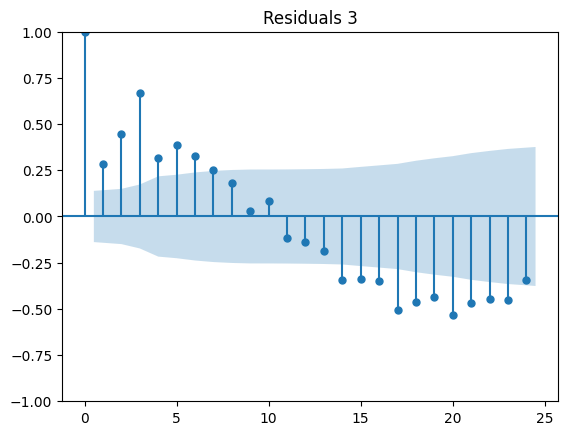

In [8]:
residuals_1 = fit_1.resid
residuals_2 = fit_2.resid
residuals_3 = fit_3.resid

plot_acf(residuals_1, title = "Residuals 1")

plot_acf(residuals_2, title = "Residuals 2")

plot_acf(residuals_3, title = "Residuals 3")

#### Residuals look a bit more like white noise but I still see the periodicity in there. Let's compare their distribution to a normal distribution using a Q-Q plot.

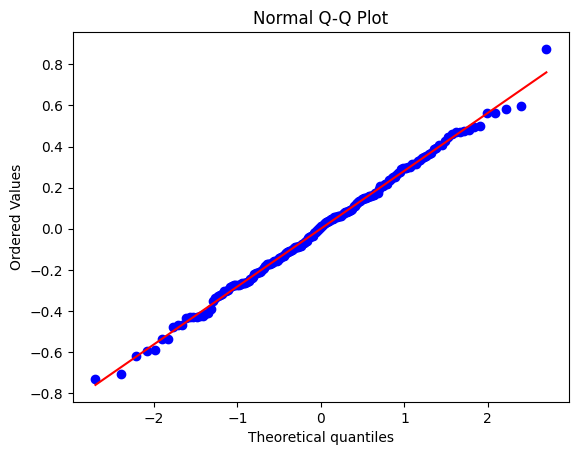

In [9]:
from scipy import stats

stats.probplot(residuals_2, dist="norm", plot=plt)

plt.title("Normal Q-Q Plot")
plt.show()

#### The residuals for our best model fit the line decently well. Let's do the Ljung Box test 

In [10]:
from statsmodels.stats.diagnostic import acorr_ljungbox

result = acorr_ljungbox(residuals_1, lags = [10], return_df=True)

print(result)

      lb_stat     lb_pvalue
10  53.149797  6.983888e-08


#### The test shows a p value of less than 0.05, indicating that we reject the null and that the residuals are still correlated, which is not surprising, because the noisy sinwave still has periodicity even with the noise, so the ARIMA model won't fit properly. Let's check descriptive statistics mean, variance, skewness, kurtosis

In [11]:
stats_result = stats.describe(residuals_2)

print(f"Mean: {stats_result.mean}")
print(f"Variance: {stats_result.variance}")
print(f"Skewness: {stats_result.skewness}")
print(f"Kurtosis: {stats_result.kurtosis}")

Mean: 0.0005282659558683645
Variance: 0.07815230496063151
Skewness: 0.011204002413224452
Kurtosis: -0.08644962743390217


#### After the stats test of the residuals, a good model will give us a mean of 0. We nearly see that here, so i'd say that is good. The variance tells us how strong our residuals are. The skewness tells us about the asymmetry of the distrubition, where positive tells us theres a tail to the right, where as negative tells us about a tail to the left, and 0 would tell us that the distribution is evenly distributed from right to left. Kurtosis tells us how heavy the tails are, where 0 means a normal distribution, positive tells us there's heavy outliers, negative tells us there lighter tails. From the results, we can see that the mean and standard deviation are close to zero, which shows that the distribution is almost even on the y axis with weak residuals, and that it is slightly skewed to the right with slightly heavier tails. 

#### Let's make a function that we can call to produce a 4-panel diagnostic figure containing a residual time series, ACF of residuals, histogram with fitted normal curve, and Q-Q plot

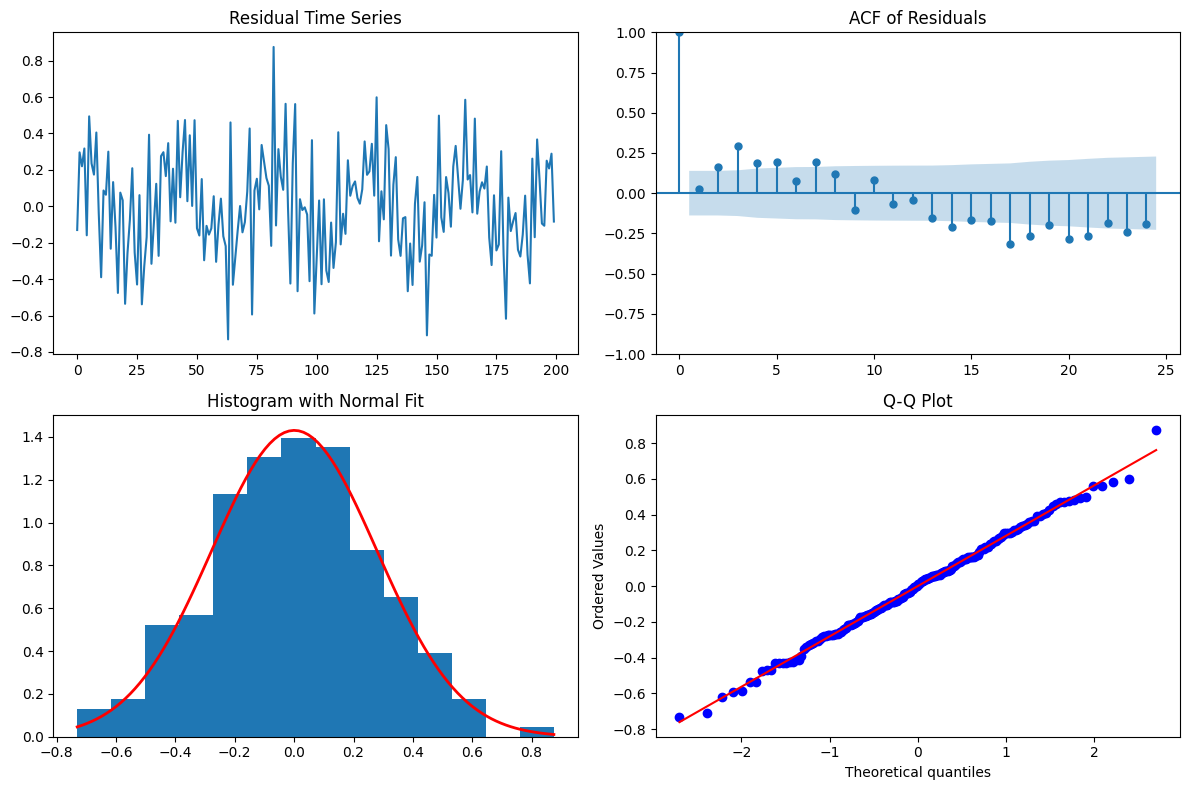

In [15]:
from scipy.stats import norm

def diagnostic_plot(residuals_2):

    fig, axes = plt.subplots(2,2,figsize=(12,8))
    
    axes[0,0].plot(residuals_2)
    axes[0,0].set_title("Residual Time Series")

    plot_acf(residuals_2, ax=axes[0,1])
    axes[0,1].set_title("ACF of Residuals")

    axes[1,0].hist(residuals_2, bins= 'auto', density = True)

    mu = np.mean(residuals_2)
    sigma = np.std(residuals_2)

    x = np.linspace(min(residuals_2), max(residuals_2), 100)
    pdf = norm.pdf(x, mu, sigma)

    axes[1, 0].plot(x, pdf, 'r-', linewidth=2)
    axes[1, 0].set_title("Histogram with Normal Fit")

    stats.probplot(residuals_2, dist="norm", plot=axes[1,1])
    axes[1,1].set_title("Q-Q Plot")

    plt.tight_layout()
    plt.show()
    
diagnostic_plot(residuals_2)    
    